# 梯度下降法：优化问题的核心引擎

$$\theta_{next} = \theta_{current} - \eta \cdot \nabla J(\theta)$$

这是一个梯度下降公式，是机器学习和数值优化领域中求解函数极值的基础性方法，其原理是不断更新$\theta$从而让函数$J(\theta)$的值变得更小，以寻求目标函数的极小值点。

当然，$\theta$并不是乱更新的：**负梯度方向是当前点处函数值下降最快的方向**，这是梯度下降法的理论基础。

在凸函数的假设下，适当选择学习率可保证算法收敛至全局最小值，而非凸函数梯度下降通常收敛至局部极小值或鞍点。

下面是通过梯度下降法寻找函数最小极值的 Python 代码

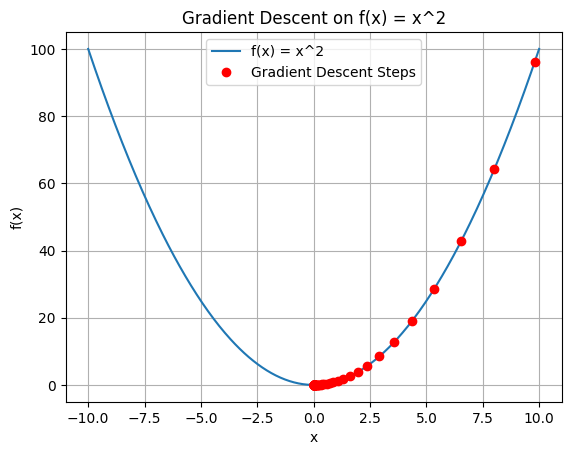

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def f(x):
    return x**2


def grad_f(x):
    return 2 * x


eta = 0.01
x = 10
# 执行梯度下降
x_history = []
y_history = []

for i in range(1000):
    x = x - eta * grad_f(x)
    if i % 10 == 0:
        x_history.append(x)
        y_history.append(f(x))
x_vals = np.linspace(-10, 10, 400)
y_vals = f(x_vals)
# 绘图
plt.plot(x_vals, y_vals, label="f(x) = x^2")  # 函数曲线
plt.plot(x_history, y_history, "ro", label="Gradient Descent Steps")  # 下降点
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.title("Gradient Descent on f(x) = x^2")
plt.grid(True)
plt.show()


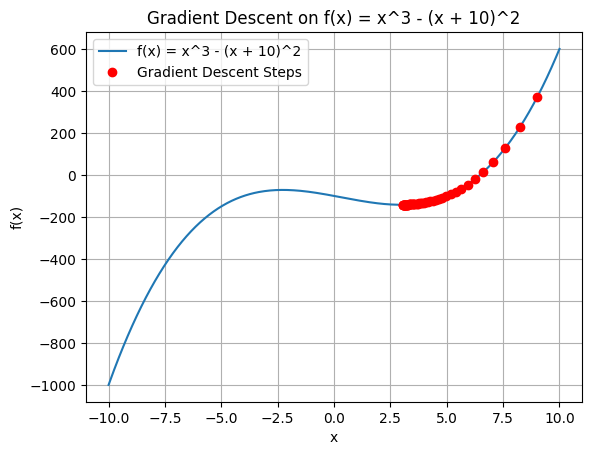

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def f(x):
    return x**3 - (x + 10) ** 2


def grad_f(x):
    return 3 * x**2 - 2 * (x + 10)


eta = 0.002
x = 10
# 执行梯度下降
x_history = []
f_history = []

for i in range(-1, 100):
    x = x - eta * grad_f(x)
    if i % 2 == 0:
        x_history.append(x)
        f_history.append(f(x))
x_vals = np.linspace(-10, 10, 400)
y_vals = f(x_vals)
# 绘图
plt.plot(x_vals, y_vals, label="f(x) = x^3 - (x + 10)^2")  # 函数曲线
plt.plot(x_history, f_history, "ro", label="Gradient Descent Steps")  # 下降点
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.title("Gradient Descent on f(x) = x^3 - (x + 10)^2")
plt.grid(True)
plt.show()


我们知道 $f(x) = x^3 - (x + 10)^2$ 的最小值是负无穷，但梯度下降法只停在了半路。这就是梯度下降法的局限性:对于非凸函数（如神经网络损失函数），梯度下降通常收敛至局部极小值。

# 损失函数：解决问题的新视角

既然本质上是寻找目标函数$J(\theta)$的最小极值，那么如果我们定义目标函数是“偏差的函数“会发生什么呢？

那么不就能通过**梯度下降法**就能得到 “偏差” 的最小极值了吗？

这样岂不是可以**假设一种分布符合一种数学模型**，然后计算出**数学模型与分布之间的偏差**的解析式，然后执行**梯度下降**让数学模型的输出与真实分布的**偏差达到极小值**

当损失值足够小时，意味着数学模型已高度拟合分布的潜在规律。此时，模型不仅能够精准**描述**已知数据的分布特征，更关键的是，它获得了对未知样本的**泛化**与**预测**能力。

## 应用：用损失函数的梯度下降求解二次方程

这是二次方程

$$x^2 - n = 0$$

我们定义损失函数（Loss Function）为平方差

$$L(x) = (x^2 - n)^2$$

根据链式求导法则 $[f(g(x))]' = f'(g(x)) \cdot g'(x)$ 令内部函数 $g(x) = x^2 - n$，则：

$$
\begin{aligned}\frac{dL}{dx} &= \frac{d}{dx}[g(x)]^2 \\
&= 2 \cdot g(x) \cdot g'(x) \\
&= 2(x^2 - n) \cdot (2x) \\
&= 4x(x^2 - n) \\
&= 4(x^3 - nx)
\end{aligned}
$$

迭代公式在梯度下降法中，参数 $x$ 的更新方向为梯度的反方向。设 $\eta$ 为学习率（Learning Rate），则第 $k+1$ 次迭代的公式为：

$$x_{k+1} = x_k - \eta \cdot \frac{dL}{dx} \bigg|_{x=x_k}$$

将推导出的导数代入得：$$x_{k+1} = x_k - \eta \cdot 4(x_k^3 - n x_k)$$

_用这个式子的原因是这个式子既可以复习链式求导又可以介绍梯度下降。如果单纯为了开方那么牛顿迭代法更高效_


In [3]:
# 把上述公式写成 Python 代码是这样


def grad_loss(x, n):  # 忽略系数，系数放进学习率里
    return x * x * x - n * x


def gd(n, eta=0.01):
    x = 1
    for _ in range(1000):
        x = x - eta * grad_loss(x, n)
    return x


# 这里是局部最优解。如果初始值设置为-1就进入了另一个局部最优解
# 学习率越小，最终值越精确，学习率越大学习速度越快，但是可能在低精度大范围震荡导致不收敛。
print(gd(2), gd(3))

1.4142135623730923 1.7320508075688756
